<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 4.7}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Giovanni Alejandri Espinosa \\[6pt]
\textbf{Fecha de realización:} & 22/04/2026
\end{array}

</center>

#Precios de Casas

A partir de la base de datos de precios de casas de Boston (Boston Housing Data), realiza la regresión de los precios de las casas con las siguientes variantes:

a. Usando minímos cuadrados

b. Aplicando regularización por norma L1 y L2

c. Seleccionando los atributos más importantes

Grafica el error de generalización de los modelos con diferentes grados del polinomio (para el inciso
a), coeficientes de regularización (para el inciso b) y número de atributos (para el inciso c). Todos los modelos deberán ser evaluados con validación cruzada de 10 particiones.

In [1]:
# Importacion de librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import make_pipeline

In [2]:
url = 'precios_casas.txt'
nombres=['per_capita', 'zona_residencial', 'acres_negocio', 'zona_rio','zona_nitoxido','habitaciones','edad','distancia_trabajo','indice_autopistas','impuesto_propiedad','num_profesores','afroamericanos','porcentaje_bajo_estatus','valor_promedio_casas']
dataset= pd.read_csv(url,delimiter='|',names=nombres)
#Verifico la información contenida en el dataset
#Con head, podremos visualizar los primeros
dataset.head(5)

,per_capita,zona_residencial,acres_negocio,zona_rio,zona_nitoxido,habitaciones,edad,distancia_trabajo,indice_autopistas,impuesto_propiedad,num_profesores,afroamericanos,porcentaje_bajo_estatus,valor_promedio_casas
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


# Parte 1: Regresión
El ejercicio solicita comparar cómo cambia el error de generalización al variar la complejidad del modelo (grados del polinomio, regularización y selección de atributos) usando validación cruzada.

In [3]:
# Preparación de datos
X = dataset.drop('valor_promedio_casas', axis=1)
y = dataset['valor_promedio_casas'].values

# 1. Regresión Lineal
# a. Mínimos Cuadrados con diferentes grados de polinomio
grados = range(1,4)
errores_poli =[]
for g in grados:
    model = make_pipeline(PolynomialFeatures(g), LinearRegression())
    mse = -cross_val_score(model, X,y, cv = 10, scoring = 'neg_mean_squared_error').mean()
    errores_poli.append(mse)

# b. Regularización L1 (Lasso) y L2 (Ridge)
alphas =[0.1,1.0,10.0]
errores_l1 = [-cross_val_score(Lasso(alpha=a),X,y,cv=10, scoring='neg_mean_squared_error').mean() for a in alphas]
errores_l2 = [-cross_val_score(Ridge(alpha=a),X,y,cv=10, scoring='neg_mean_squared_error').mean() for a in alphas]


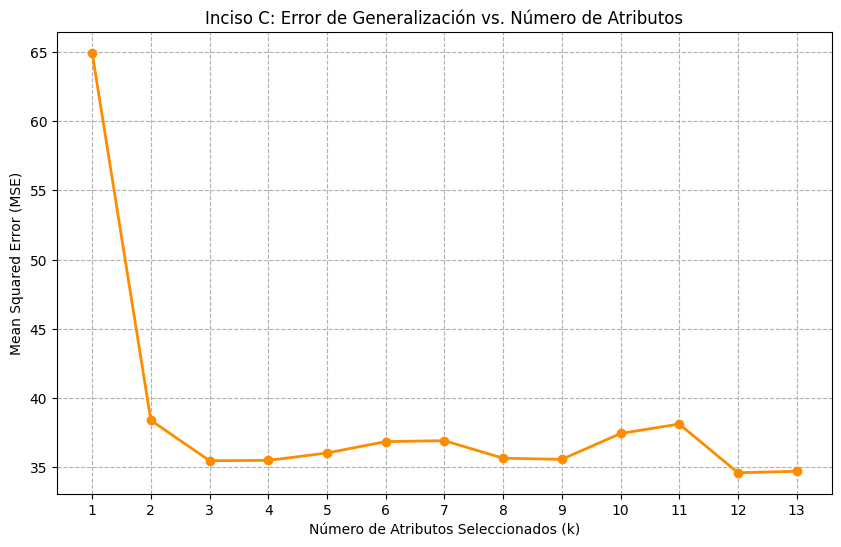

Los 5 atributos más influyentes son: ['acres_negocio', 'habitaciones', 'impuesto_propiedad', 'num_profesores', 'porcentaje_bajo_estatus']


In [4]:
from sklearn.feature_selection import SelectKBest, f_regression

# c. Selección de los n atributos más importantes
# Probaremos desde 1 atributo hasta el total de columnas (13)
num_atributos = range(1, X.shape[1] + 1)
errores_kbest = []

for k in num_atributos:
    # El pipeline primero selecciona las k mejores variables y luego entrena la regresión
    model_k = make_pipeline(
        SelectKBest(score_func=f_regression, k=k),
        LinearRegression()
    )
    # Evaluación con validación cruzada de 10 particiones
    mse = -cross_val_score(model_k, X, y, cv=10, scoring='neg_mean_squared_error').mean()
    errores_kbest.append(mse)

# --- VISUALIZACIÓN DEL INCISO C ---
plt.figure(figsize=(10, 6))
plt.plot(num_atributos, errores_kbest, marker='o', color='darkorange', linewidth=2)
plt.title('Inciso C: Error de Generalización vs. Número de Atributos')
plt.xlabel('Número de Atributos Seleccionados (k)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(num_atributos)
plt.grid(True, linestyle='--')
plt.show()

# Extra para la clase: ¿Cuáles son esos atributos?
selector = SelectKBest(score_func=f_regression, k=5).fit(X, y)
print(f"Los 5 atributos más influyentes son: {list(X.columns[selector.get_support()])}")

#Parte 2: Aprendizaje No Supervisado y Anomalías
Si quisiéramos analizar este dataset desde una perspectiva no supervisada (por ejemplo, para agrupar tipos de vecindarios o encontrar casas con precios/características "extrañas"), aplicaríamos lo siguiente:

##1. Clustering (K-Means y DBSCAN)
Aquí ignoramos el precio y buscamos patrones intrínsecos en las características de las zonas.

In [5]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Escalado es vital para algoritmos basados en distancia
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. K-Means
# K-Means (requiere definir K, ej. 3 grupos de zonas)
kmeans = KMeans(n_clusters= 3, random_state= 42).fit(X_scaled)


# DBSCAN (basado en densidad, ideal para formas irregulares)
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X_scaled)


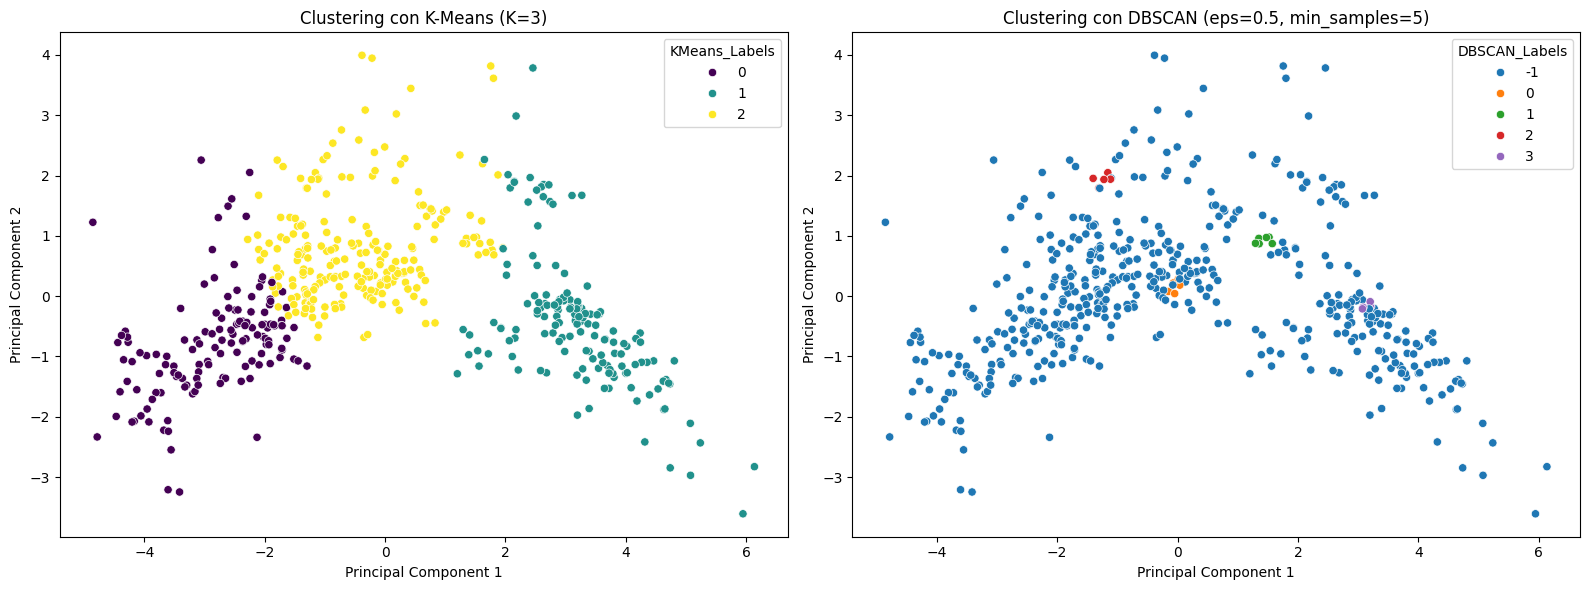

In [6]:
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Reducimos a 2 dimensiones para poder graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Creamos un DataFrame para graficar fácilmente con Seaborn
df_viz = pd.DataFrame(X_pca, columns=['Componente 1', 'Componente 2'])
df_viz['KMeans_Labels'] = kmeans.labels_
df_viz['DBSCAN_Labels'] = dbscan.labels_

# 3. Visualización comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica K-Means
sns.scatterplot(data=df_viz, x='Componente 1', y='Componente 2',
                hue='KMeans_Labels', palette='viridis', ax=ax1)
ax1.set_title('Clustering con K-Means (K=3)')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

# Gráfica DBSCAN
sns.scatterplot(data=df_viz, x='Componente 1', y='Componente 2',
                hue='DBSCAN_Labels', palette='tab10', ax=ax2)
ax2.set_title('Clustering con DBSCAN (eps=0.5, min_samples=5)')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

##2. Detección de Anomalías (Isolation Forest)
Esto es excelente para identificar registros que se comportan de forma atípica (casas con precios sospechosamente bajos o niveles de polución inusuales).

In [7]:
from sklearn.ensemble import IsolationForest

# Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42) # Esperamos 5% de anomalías
anomalias = iso_forest.fit_predict(X_scaled)

# -1 indica anomalía, 1 indica registro normal
dataset['es_anomalia'] = anomalias


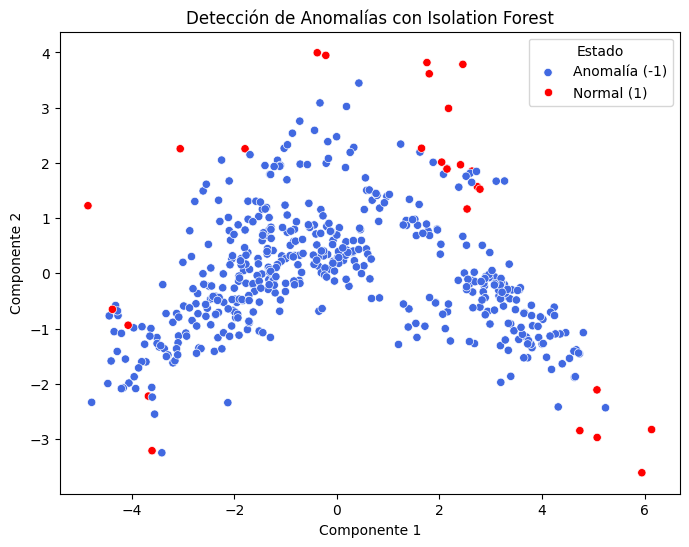

Se han detectado 26 casos atípicos en el dataset.


In [8]:
from sklearn.ensemble import IsolationForest

# 1. Configuración del modelo
# contamination=0.05 significa que esperamos que el 5% de los datos sean anomalías
#iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df_viz['Anomaly_Labels'] = iso_forest.fit_predict(X_scaled)

# 2. Visualización
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_viz, x='Componente 1', y='Componente 2',
                hue='Anomaly_Labels', palette={1: 'royalblue', -1: 'red'})

plt.title('Detección de Anomalías con Isolation Forest')
plt.legend(title='Estado', labels=['Anomalía (-1)', 'Normal (1)'])
plt.show()

# 3. Imprimir cuántas anomalías se detectaron
num_anomalias = (df_viz['Anomaly_Labels'] == -1).sum()
print(f"Se han detectado {num_anomalias} casos atípicos en el dataset.")

#Conclusión

En esta práctica se compararon distintos modelos de regresión para predecir precios de casas, analizando cómo cambia el error al modificar la complejidad del modelo. Se observó que aumentar el grado del polinomio o el número de atributos no siempre mejora los resultados, ya que puede provocar sobreajuste. Métodos como Ridge y Lasso ayudan a controlar este problema al regular los coeficientes. En general, se concluye que es importante encontrar un equilibrio entre complejidad y capacidad de generalización para obtener mejores predicciones.

#Bibliografía

Bibliografía

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
- Murphy, K. P. (2022). Probabilistic Machine Learning: An Introduction. MIT Press.
- Russell, S. J., & Norvig, P. (2020). Artificial Intelligence: A Modern Approach (4th ed.). Pearson.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>